In [ ]:
import pandas as pd
import numpy as np 
import matplotlib.pyplot as plt 
import seaborn as sns

sns.set_theme(style="whitegrid")

In [16]:

# Configuration esthétique
pio.renderers.default = "browser"
sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams['figure.figsize'] = (12, 6)

df_exposure = pd.read_csv("Data/exposure_and_game_info/exposure_results_final.csv")
df_metadata = pd.read_csv("Data/urls/game_highlight_urls.csv")
df_game_info = pd.read_csv("Data/exposure_and_game_info/nba_games_2025-26.csv")

df = pd.merge(df_exposure, df_metadata.drop(columns=['game_id', 'title', 'url']), on="video_id", how='left')
df = pd.merge(df, df_game_info[['GAME_ID', 'HOME_TEAM_ID', "HOME_TEAM_NAME", 'AWAY_TEAM_ID', "AWAY_TEAM_NAME"]], left_on='game_id', right_on='GAME_ID', how='left')

print(f"DataFrame chargé avec succès. Dimensions : {df.shape}")
display(df.head())

DataFrame chargé avec succès. Dimensions : (4360, 16)


,game_id,video_id,exposure_zone,exposure_time_seconds,average_box_area_pixels,video_url,channel,duration,view_count,like_count,comment_count,GAME_ID,HOME_TEAM_ID,HOME_TEAM_NAME,AWAY_TEAM_ID,AWAY_TEAM_NAME
0,22500050,qCZWwFr0pA0,side-court-led-logo,512.2,2018.40,https://www.youtube.com/watch?v=qCZWwFr0pA0,GAMETIME HIGHLIGHTS,569,18970,220,6.0,22500050,1610612761,Toronto Raptors,1610612764,Washington Wizards
1,22500050,qCZWwFr0pA0,mid-court-logo,489.6,3719.37,https://www.youtube.com/watch?v=qCZWwFr0pA0,GAMETIME HIGHLIGHTS,569,18970,220,6.0,22500050,1610612761,Toronto Raptors,1610612764,Washington Wizards
2,22500050,qCZWwFr0pA0,side-court-logo,396.2,1783.58,https://www.youtube.com/watch?v=qCZWwFr0pA0,GAMETIME HIGHLIGHTS,569,18970,220,6.0,22500050,1610612761,Toronto Raptors,1610612764,Washington Wizards
3,22500050,qCZWwFr0pA0,back-court-logo,460.0,2807.39,https://www.youtube.com/watch?v=qCZWwFr0pA0,GAMETIME HIGHLIGHTS,569,18970,220,6.0,22500050,1610612761,Toronto Raptors,1610612764,Washington Wizards
4,22500050,qCZWwFr0pA0,basket-logo,445.8,630.69,https://www.youtube.com/watch?v=qCZWwFr0pA0,GAMETIME HIGHLIGHTS,569,18970,220,6.0,22500050,1610612761,Toronto Raptors,1610612764,Washington Wizards


--- STATISTIQUES GÉNÉRALES ---
Nombre de matchs couverts : 232
Nombre de vidéos analysées : 880
------------------------------
Vues Totales cumulées   : 68,202,278
Likes Totaux cumulés    : 813,129
Commentaires cumulés    : 59,410


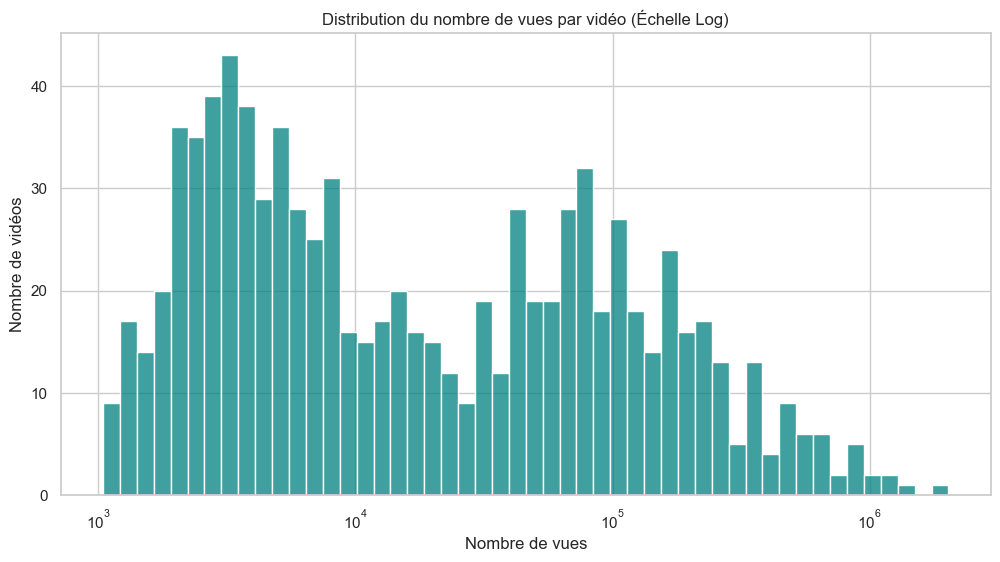


--- TOP 5 MATCHS (Vues Cumulées) ---


HOME_TEAM_NAME         AWAY_TEAM_NAME        
Los Angeles Lakers     Golden State Warriors     2338724
San Antonio Spurs      Golden State Warriors     1779851
Golden State Warriors  Memphis Grizzlies         1700547
Los Angeles Lakers     San Antonio Spurs         1693276
                       Minnesota Timberwolves    1632823
Name: view_count, dtype: int64

In [17]:
# Création d'un DF unique par vidéo pour les stats d'audience
df_videos = df.drop_duplicates(subset='video_id')

print("--- STATISTIQUES GÉNÉRALES ---")
print(f"Nombre de matchs couverts : {df['game_id'].nunique()}")
print(f"Nombre de vidéos analysées : {df['video_id'].nunique()}")
print("-" * 30)
print(f"Vues Totales cumulées   : {df_videos['view_count'].sum():,.0f}")
print(f"Likes Totaux cumulés    : {df_videos['like_count'].sum():,.0f}")
print(f"Commentaires cumulés    : {df_videos['comment_count'].sum():,.0f}")

# Distribution des vues (Echelle Logarithmique car souvent très asymétrique)
plt.figure(figsize=(12, 6))
sns.histplot(df_videos['view_count'], bins=50, log_scale=True, color='teal')
plt.title("Distribution du nombre de vues par vidéo (Échelle Log)")
plt.xlabel("Nombre de vues")
plt.ylabel("Nombre de vidéos")
plt.show()

# Top 5 des matchs les plus vus (toutes vidéos confondues)
top_games = df_videos.groupby(['HOME_TEAM_NAME', 'AWAY_TEAM_NAME'])['view_count'].sum().sort_values(ascending=False).head(5)
print("\n--- TOP 5 MATCHS (Vues Cumulées) ---")
display(top_games)

C:\Users\Kyliv\AppData\Local\Temp\ipykernel_60544\1977414474.py:9: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.




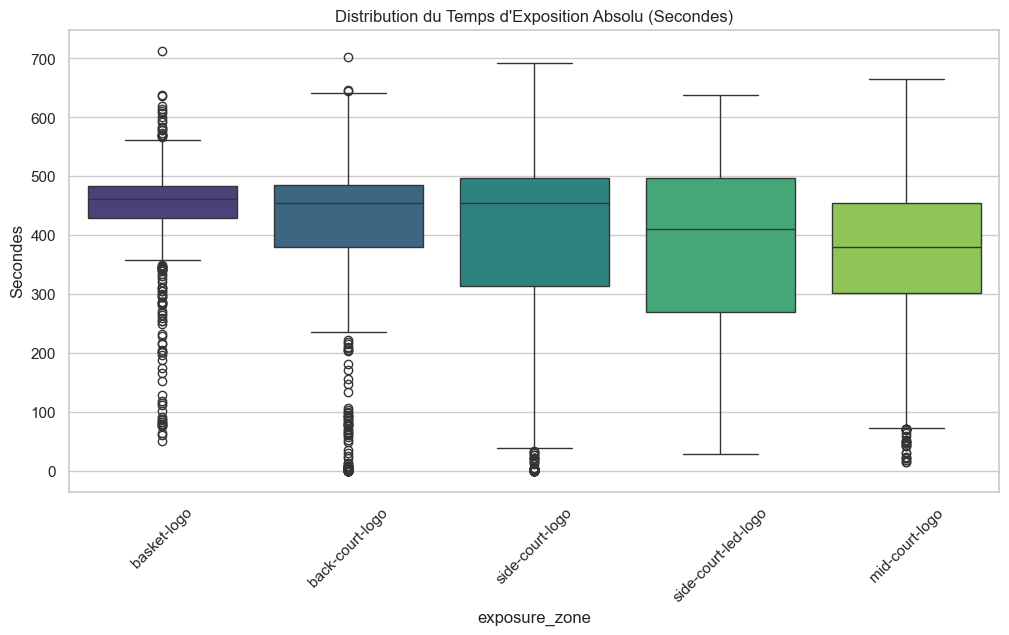

C:\Users\Kyliv\AppData\Local\Temp\ipykernel_60544\1977414474.py:17: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.




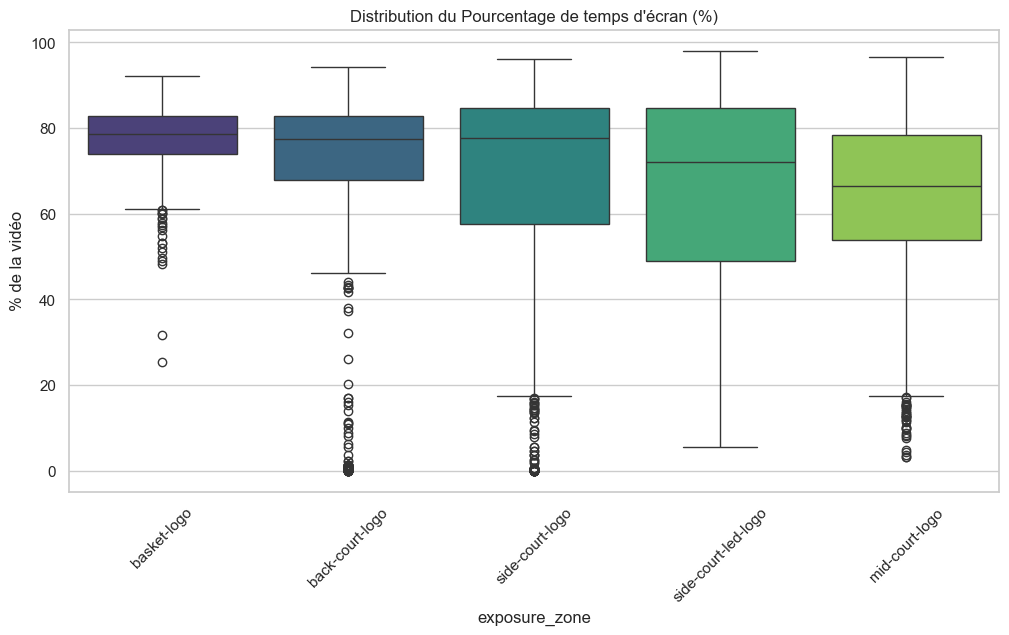

In [19]:
# Calcul du pourcentage 
df['percentage_exposition'] = (df['exposure_time_seconds'] / df['duration']) * 100

# Ordre de tri pour les graphiques (du plus exposé au moins exposé)
order_by_time = df.groupby("exposure_zone")["exposure_time_seconds"].median().sort_values(ascending=False).index

# 1. Temps Absolu
plt.figure(figsize=(12, 6))
sns.boxplot(x="exposure_zone", y="exposure_time_seconds", data=df, order=order_by_time, palette="viridis")
plt.title("Distribution du Temps d'Exposition Absolu (Secondes)")
plt.xticks(rotation=45)
plt.ylabel("Secondes")
plt.show()

# 2. Temps Relatif (%)
plt.figure(figsize=(12, 6))
sns.boxplot(x="exposure_zone", y="percentage_exposition", data=df, order=order_by_time, palette="viridis")
plt.title("Distribution du Pourcentage de temps d'écran (%)")
plt.xticks(rotation=45)
plt.ylabel("% de la vidéo")
plt.show()

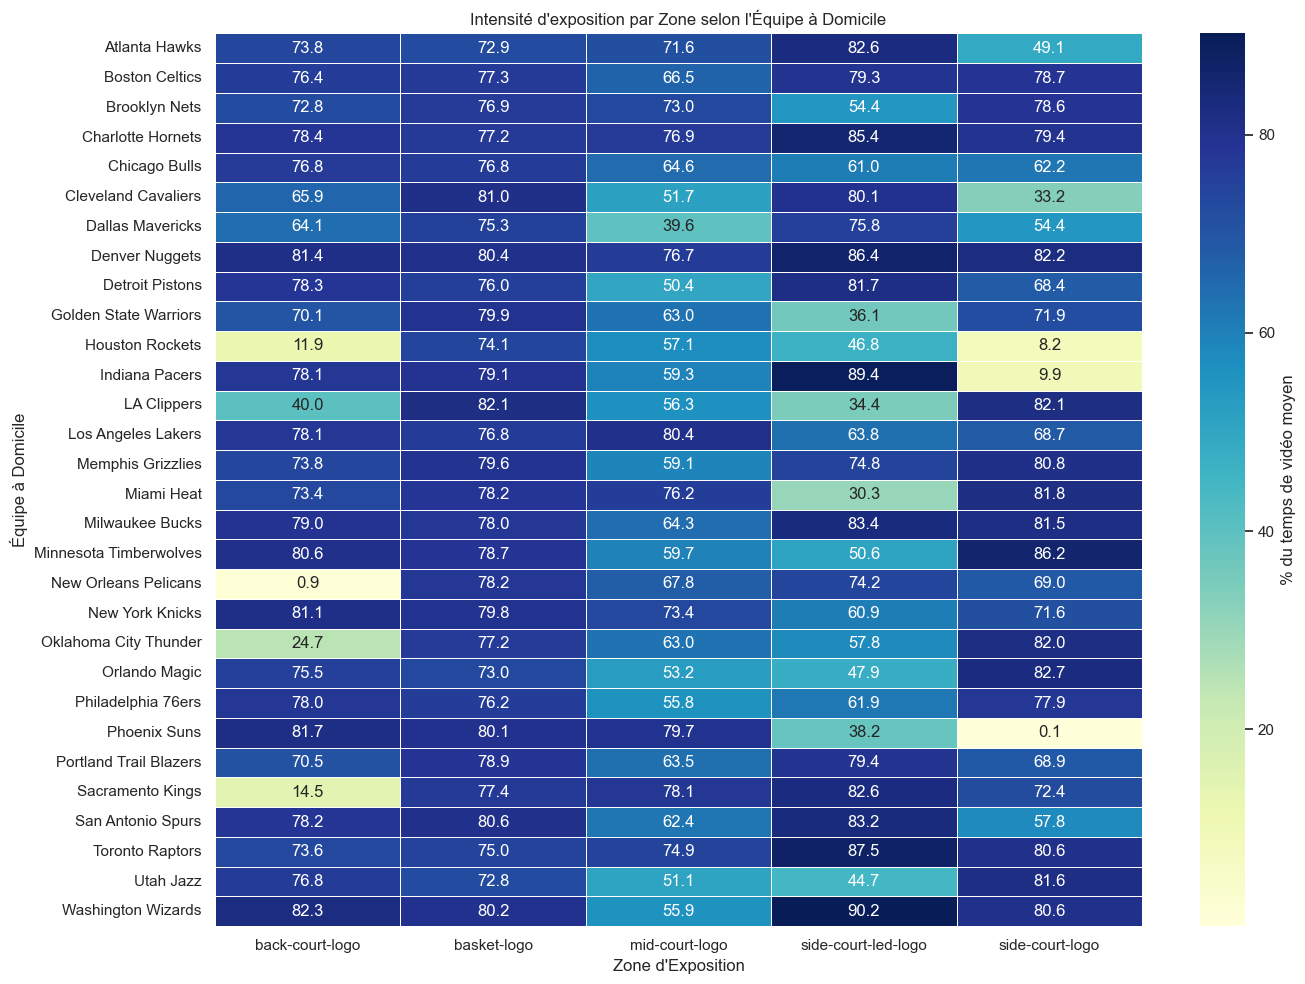

In [20]:
# Agrégation par équipe domicile et zone
s = df.groupby(['HOME_TEAM_NAME', 'exposure_zone'])['percentage_exposition'].mean()
df_heatmap = s.reset_index().pivot(index="HOME_TEAM_NAME", columns="exposure_zone", values="percentage_exposition")

plt.figure(figsize=(14, 10))
sns.heatmap(
    df_heatmap,
    cmap="YlGnBu", # Palette plus lisible pour l'intensité
    annot=True,    # Affiche les valeurs
    fmt=".1f",     # 1 chiffre après la virgule
    linewidths=.5,
    cbar_kws={"label": "% du temps de vidéo moyen"}
)
plt.title("Intensité d'exposition par Zone selon l'Équipe à Domicile")
plt.ylabel("Équipe à Domicile")
plt.xlabel("Zone d'Exposition")
plt.tight_layout()
plt.show()

C:\Users\Kyliv\AppData\Local\Temp\ipykernel_60544\1833554865.py:5: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.




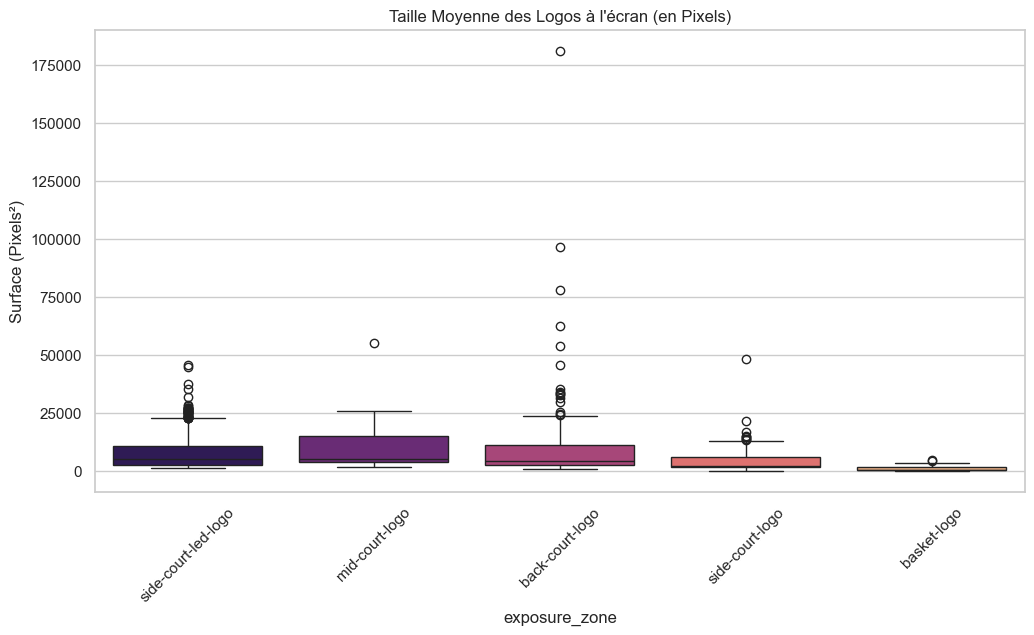

C:\Users\Kyliv\AppData\Local\Temp\ipykernel_60544\1833554865.py:12: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.




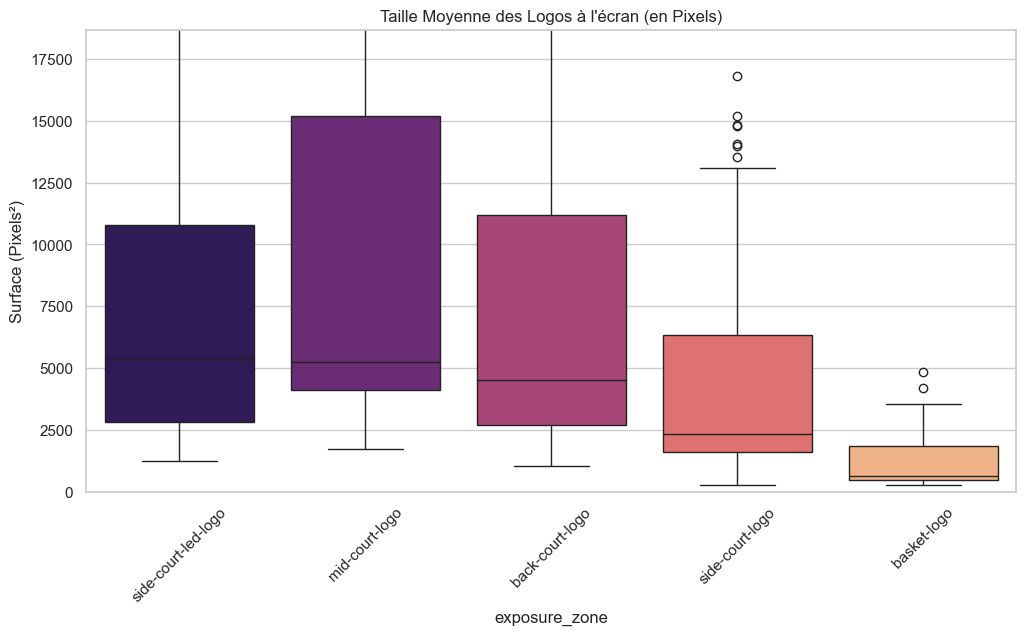

In [22]:
# Tri par taille moyenne
order_by_size = df.groupby("exposure_zone")["average_box_area_pixels"].median().sort_values(ascending=False).index

plt.figure(figsize=(12, 6))
sns.boxplot(x="exposure_zone", y="average_box_area_pixels", data=df, order=order_by_size, palette="magma")
plt.title("Taille Moyenne des Logos à l'écran (en Pixels)")
plt.xticks(rotation=45)
plt.ylabel("Surface (Pixels²)")
plt.show()

plt.figure(figsize=(12, 6))
sns.boxplot(x="exposure_zone", y="average_box_area_pixels", data=df, order=order_by_size, palette="magma")
plt.title("Taille Moyenne des Logos à l'écran (en Pixels)")
plt.xticks(rotation=45)
plt.ylabel("Surface (Pixels²)")

# On limite l'axe Y pour mieux voir les petites zones (en excluant les outliers extrêmes)
# On prend le 95ème percentile pour couper les valeurs extrêmes
ymax = df['average_box_area_pixels'].quantile(0.95)
plt.ylim(0, ymax)
plt.show()

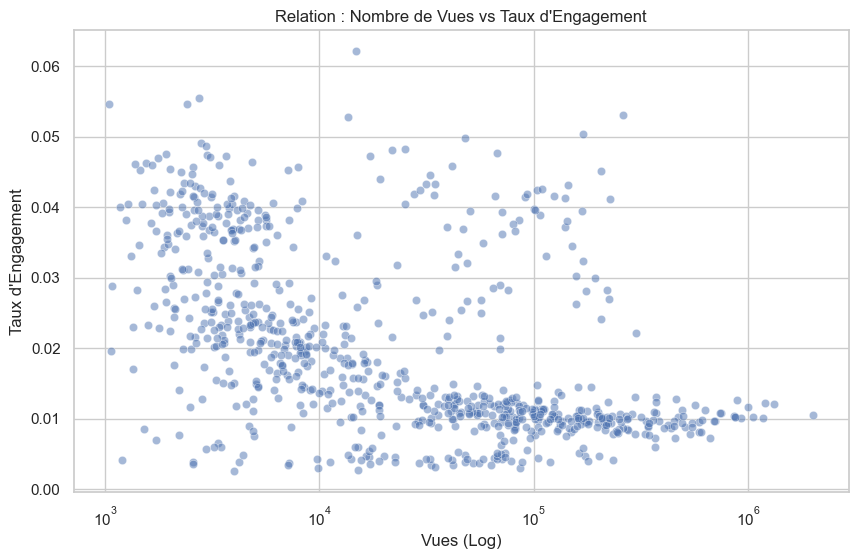

C:\Users\Kyliv\AppData\Local\Temp\ipykernel_60544\2195010469.py:31: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.




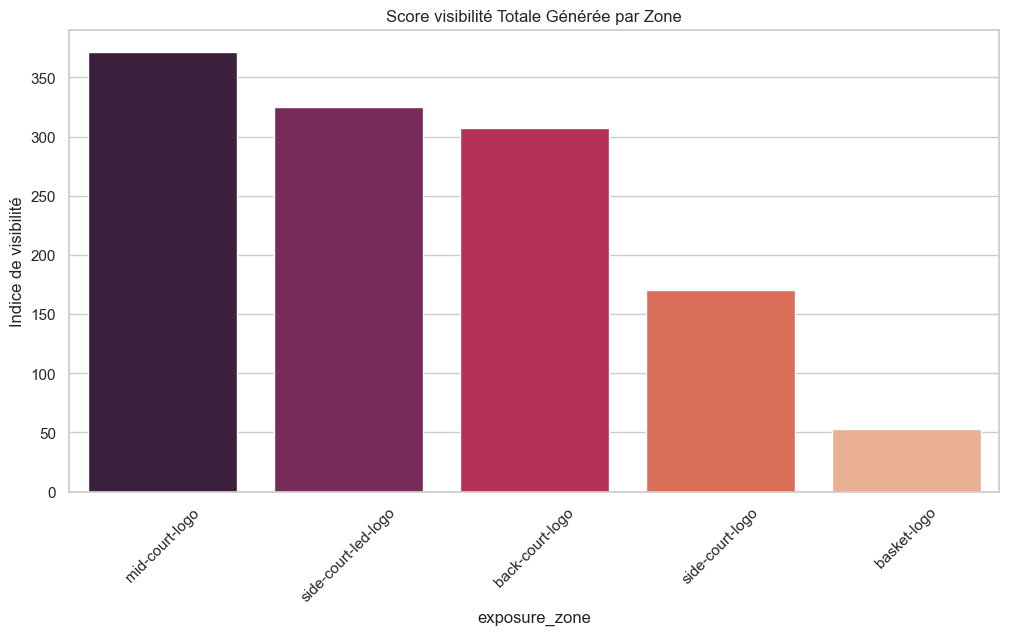

C:\Users\Kyliv\AppData\Local\Temp\ipykernel_60544\2195010469.py:48: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.




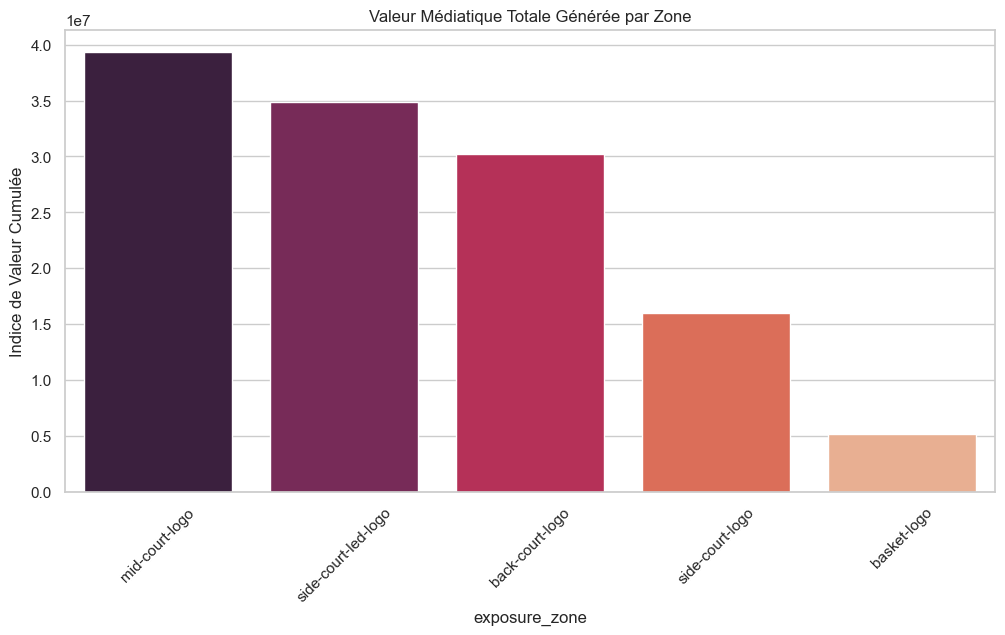

In [32]:
# --- 1. Score d'Engagement ---
# On ajoute 1 au dénominateur pour éviter la division par zéro
df['engagement_rate'] = (df['like_count'] + df['comment_count']) / (df['view_count'] + 1)

# Visualisation relation Vues vs Engagement
plt.figure(figsize=(10, 6))
sns.scatterplot(data=df.drop_duplicates('video_id'), x='view_count', y='engagement_rate', alpha=0.5)
plt.xscale('log') # Echelle log car les vues varient énormément
plt.title("Relation : Nombre de Vues vs Taux d'Engagement")
plt.xlabel("Vues (Log)")
plt.ylabel("Taux d'Engagement")
plt.show()


# --- 2. Score de Visibilité (Quality Index) ---

# Résolution 720p (1280 x 720)
SCREEN_WIDTH = 1280
SCREEN_HEIGHT = 720
SCREEN_AREA = SCREEN_WIDTH * SCREEN_HEIGHT  # 921,600 pixels

# Part d'écran (Screen Share) : Quelle fraction de l'écran le logo occupe-t-il ?
df['screen_share_percent'] = (df['average_box_area_pixels'] / SCREEN_AREA)

# Score de Visibilité : Temps * Part d'écran
# Unité : "Secondes-Écran" (ex: 10 secondes à 10% de l'écran = score de 1)
# On multiplie par 100 pour avoir des chiffres plus lisibles
df['visibility_score'] = df['exposure_time_seconds'] * df['screen_share_percent'] * 100

plt.figure(figsize=(12, 6))
sns.barplot(x="exposure_zone", y="visibility_score", data=df, errorbar=None, order=order_by_value, palette="rocket")
plt.title("Score visibilité Totale Générée par Zone")
plt.ylabel("Indice de visibilité")
plt.xticks(rotation=45)
plt.show()

# --- 3. Valeur Totale (Total Media Value) ---
# Formule : Score de visibilité * Vues * (Boost d'engagement)
df['media_value_index'] = df['visibility_score'] * df['view_count'] * (1 + df['engagement_rate'])


# --- Visualisation des résultats finaux ---

# Comparaison des zones par valeur générée
order_by_value = df.groupby("exposure_zone")["media_value_index"].median().sort_values(ascending=False).index

plt.figure(figsize=(12, 6))
sns.barplot(x="exposure_zone", y="media_value_index", data=df, errorbar=None, order=order_by_value, palette="rocket")
plt.title("Valeur Médiatique Totale Générée par Zone")
plt.ylabel("Indice de Valeur Cumulée")
plt.xticks(rotation=45)
plt.show()